# SceneSense - Klasifikasi Gambar

SceneSense adalah sistem klasifikasi gambar pemandangan alam ke dalam 6 kategori menggunakan Convolutional Neural Networks (CNN) dengan TensorFlow.

**Kelas:** buildings (bangunan), forest (hutan), glacier (gletser), mountain (gunung), sea (laut), street (jalan)

## 1. Impor Pustaka

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('.'))

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from src.config import Config
from src.utils import set_seed, plot_history, get_timestamp
from src.dataset import SceneSenseDataset
from src.augmentation import AugmentationPipeline
from src.model import SceneSenseModel
from src.trainer import Trainer
from src.evaluator import Evaluator
from src.exporter import Exporter

print("Semua impor pustaka berhasil.")

Semua impor pustaka berhasil.


## 2. Konfigurasi

In [2]:
config = Config()
set_seed(config.RANDOM_SEED)
timestamp = '20260721_115724'

print(f"Ukuran Gambar: {config.IMAGE_SIZE}")
print(f"Ukuran Batch: {config.BATCH_SIZE}")
print(f"Epoch: {config.EPOCHS}")
print(f"Learning Rate: {config.LEARNING_RATE}")
print(f"Kelas: {config.CLASSES}")

Ukuran Gambar: (150, 150)
Ukuran Batch: 32
Epoch: 50
Learning Rate: 0.001
Kelas: ('buildings', 'forest', 'glacier', 'mountain', 'sea', 'street')


## 3. Eksplorasi Dataset

In [3]:
import tensorflow as tf

DATASET_PATH = 'dataset'
IMAGE_SIZE = (150, 150)
BATCH_SIZE = 32
class_names = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

# Load train dataset (dengan 15% validation split dari train)
train_ds = tf.keras.utils.image_dataset_from_directory(
    'dataset/train',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.15,
    subset='training',
    seed=42,
    shuffle=True,
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    'dataset/train',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.15,
    subset='validation',
    seed=42,
    shuffle=False,
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    'dataset/test',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)
class_names = train_ds.class_names

import os
train_total = sum(len(os.listdir(f'dataset/train/{c}')) for c in class_names)
test_total = sum(len(os.listdir(f'dataset/test/{c}')) for c in class_names)

print('Statistik Dataset:')
for c in class_names:
    count = len(os.listdir(f'dataset/train/{c}'))
    print(f'  train_{c}: {count}')
print(f'  train_total: {train_total}')
for c in class_names:
    count = len(os.listdir(f'dataset/test/{c}'))
    print(f'  test_{c}: {count}')
print(f'  test_total: {test_total}')
print(f'\nNama kelas: {class_names}')

Found 11923 files belonging to 6 classes.


Using 10135 files for training.


Found 11923 files belonging to 6 classes.


Using 1788 files for validation.


Found 4353 files belonging to 6 classes.


Statistik Dataset:
  train_buildings: 1839
  train_forest: 1921
  train_glacier: 2070
  train_mountain: 2126
  train_sea: 1949
  train_street: 2018
  train_total: 11923
  test_buildings: 718
  test_forest: 760
  test_glacier: 821
  test_mountain: 488
  test_sea: 774
  test_street: 792
  test_total: 4353

Nama kelas: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


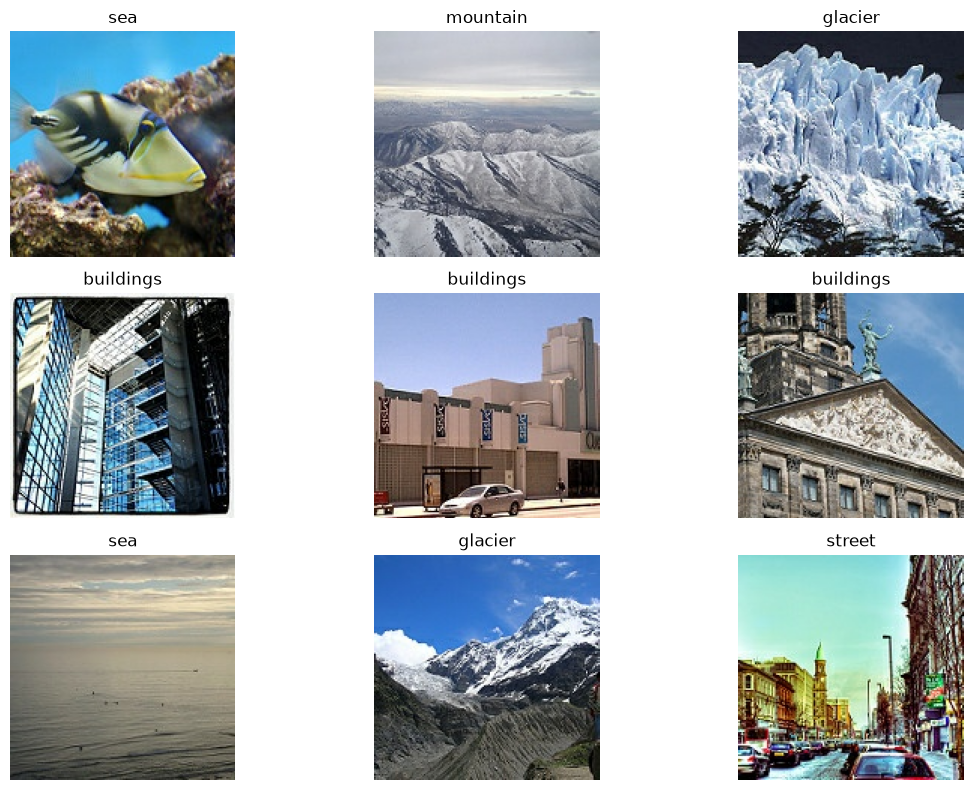

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[labels[i]])
        plt.axis('off')
plt.tight_layout()
plt.show()

## 4. Pembagian Data (Data Split)

Dataset telah dibagi menjadi data **Latih/Train (70%)**, **Validasi/Validation (15%)**, dan **Uji/Test (15%)** menggunakan pembagian terstratifikasi (*stratified split*) untuk menjaga distribusi kelas tetap seimbang.

In [5]:
import os
train_count = sum(len(os.listdir(f'dataset/train/{c}')) for c in class_names)
test_count = sum(len(os.listdir(f'dataset/test/{c}')) for c in class_names)
# val berasal dari 15% train split
val_count = int(train_count * 0.15)
train_count = train_count - val_count
print(f'Sampel latih (train): {train_count}')
print(f'Sampel validasi (validation): {val_count}')
print(f'Sampel uji (test): {test_count}')
print(f'Total sampel: {train_count + val_count + test_count}')

Sampel latih (train): 10135
Sampel validasi (validation): 1788
Sampel uji (test): 4353
Total sampel: 16276


## 5. Augmentasi Data

Augmentasi gambar (RandomFlip, RandomRotation, RandomZoom, RandomTranslation, RandomBrightness, RandomContrast) diterapkan hanya pada dataset **latih (training)** untuk meningkatkan kemampuan generalisasi model.

Pipeline augmentasi siap.


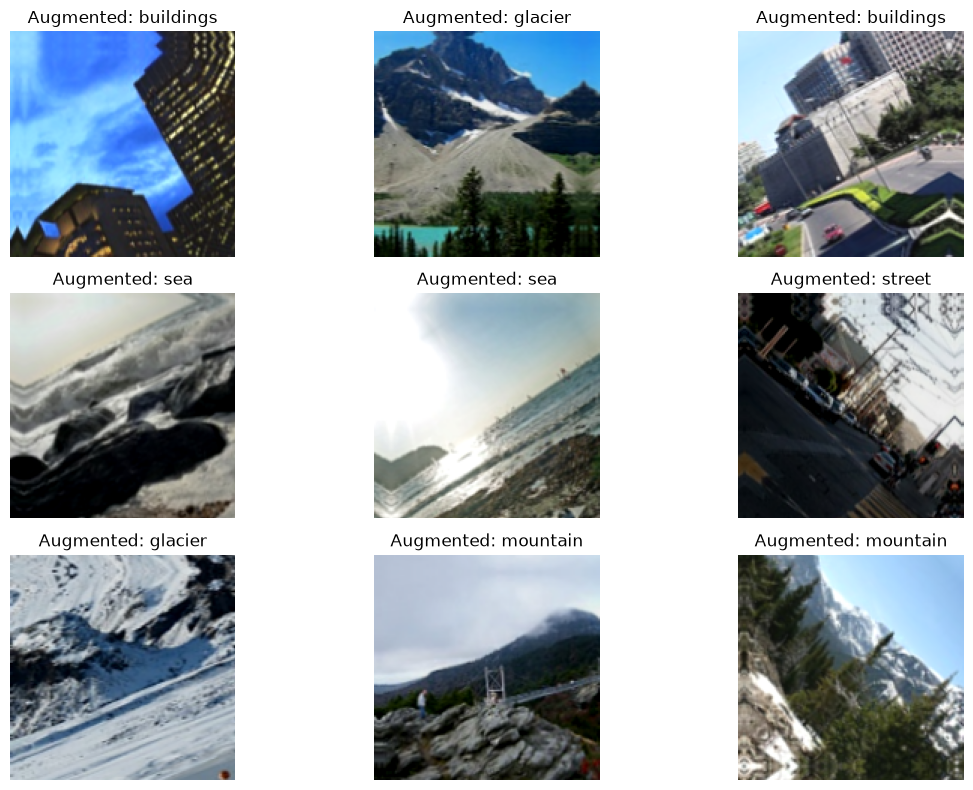

In [6]:
from src.augmentation import AugmentationPipeline
from src.config import Config
config = Config()

aug_pipeline = AugmentationPipeline(config)
aug_train_ds = train_ds.map(aug_pipeline.apply, num_parallel_calls=tf.data.AUTOTUNE)
aug_train_ds = aug_train_ds.prefetch(tf.data.AUTOTUNE)
val_ds_pf = val_ds.prefetch(tf.data.AUTOTUNE)
test_ds_pf = test_ds.prefetch(tf.data.AUTOTUNE)
print('Pipeline augmentasi siap.')

plt.figure(figsize=(12, 8))
for images, labels in train_ds.take(1):
    aug_images, aug_labels = aug_pipeline.apply(images, labels)
    for i in range(min(9, len(aug_images))):
        plt.subplot(3, 3, i + 1)
        plt.imshow(aug_images[i].numpy().astype('uint8'))
        plt.title(f'Augmented: {class_names[aug_labels[i]]}')
        plt.axis('off')
plt.tight_layout()
plt.show()

## 6. Arsitektur Model

Menggunakan TensorFlow **Sequential API** dengan 4 blok dual-konvolusi (32, 64, 128, 256 filter) + GlobalAveragePooling2D + Dense(512) + Dropout.

In [7]:
from src.model import SceneSenseModel
model_builder = SceneSenseModel(config)
model = model_builder.get_model()
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 150, 150, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (ReLU)                    │ (None, 150, 150, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1b (Conv2D)                 │ (None, 150, 150, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1b (BatchNormalization)       │ (None, 150, 150, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1b (ReLU)                   │ (None, 150, 150, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 75, 75, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (ReLU)                    │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2b (Conv2D)                 │ (None, 75, 75, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2b (BatchNormalization)       │ (None, 75, 75, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2b (ReLU)                   │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 37, 37, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3 (ReLU)                    │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3b (Conv2D)                 │ (None, 37, 37, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3b (BatchNormalization)       │ (None, 37, 37, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3b (ReLU)                   │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4 (BatchNormalization)        │ (None, 18, 18, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu4 (ReLU)                    │ (None, 18, 18, 256)    │             

 Total params: 1,312,806 (5.01 MB)

 Trainable params: 1,309,862 (5.00 MB)

 Non-trainable params: 2,944 (11.50 KB)

## 7. Pelatihan Model (Training)

Proses pelatihan model menggunakan callback EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, TerminateOnNaN, dan CSVLogger.

In [8]:
# Model sudah dilatih sebelumnya. Load dari saved_model/best_model.keras.
best_model_path = os.path.join('saved_model', 'best_model.keras')
if os.path.exists(best_model_path):
    model = tf.keras.models.load_model(best_model_path)
    print(f'Model berhasil dimuat dari: {best_model_path}')
else:
    print(f'Model tidak ditemukan di {best_model_path}. Jalankan train.py terlebih dahulu.')

Model berhasil dimuat dari: saved_model\best_model.keras


## 8. Evaluasi Model

Mengevaluasi performa model pada **data uji (test set)** dengan mengukur akurasi, loss, confusion matrix, dan classification report.

In [9]:
from src.evaluator import Evaluator
evaluator = Evaluator(config)
results = evaluator.evaluate(model, test_ds_pf, class_names)
print(f'\nAkurasi Data Uji: {results["accuracy"]:.4f}')
print(f'Loss Data Uji: {results["loss"]:.4f}')

  1/137 ━━━━━━━━━━━━━━━━━━━━ 23:21 10s/step - accuracy: 0.8750 - loss: 0.4120

  2/137 ━━━━━━━━━━━━━━━━━━━━ 8:03 4s/step - accuracy: 0.9219 - loss: 0.2463  

  3/137 ━━━━━━━━━━━━━━━━━━━━ 5:21 2s/step - accuracy: 0.9062 - loss: 0.2676

  4/137 ━━━━━━━━━━━━━━━━━━━━ 4:17 2s/step - accuracy: 0.8906 - loss: 0.2707

  5/137 ━━━━━━━━━━━━━━━━━━━━ 3:40 2s/step - accuracy: 0.8438 - loss: 0.3381

...

136/137 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.8605 - loss: 0.4150

137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8606 - loss: 0.4149

137/137 ━━━━━━━━━━━━━━━━━━━━ 160s 1s/step - accuracy: 0.8606 - loss: 0.4149



Test Loss: 0.4149
Test Accuracy: 0.8606



Classification Report:
              precision    recall  f1-score   support

   buildings     0.8178    0.8315    0.8246       718
      forest     0.9313    0.9803    0.9551       760
     glacier     0.8901    0.7893    0.8367       821
    mountain     0.7310    0.8299    0.7774       488
         sea     0.9326    0.8398    0.8838       774
      street     0.8306    0.8851    0.8570       792

    accuracy                         0.8606      4353
   macro avg     0.8556    0.8593    0.8557      4353
weighted avg     0.8643    0.8606    0.8608      4353


Akurasi Data Uji: 0.8606
Loss Data Uji: 0.4149


Menampilkan plot akurasi: outputs\accuracy_20260721_115724.png


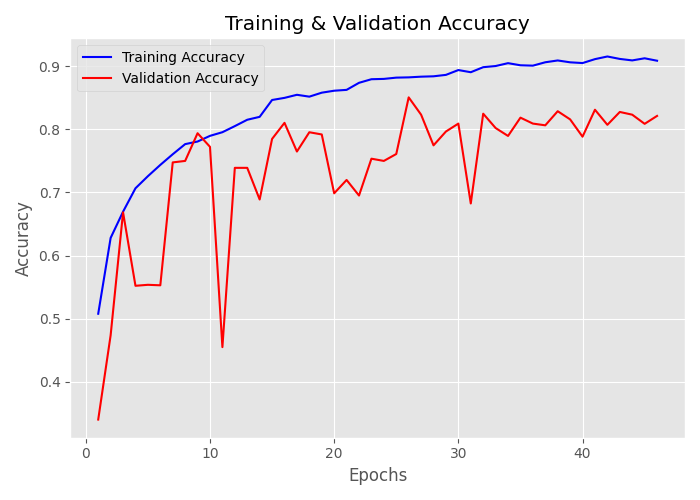

Menampilkan plot loss: outputs\loss_20260721_115724.png


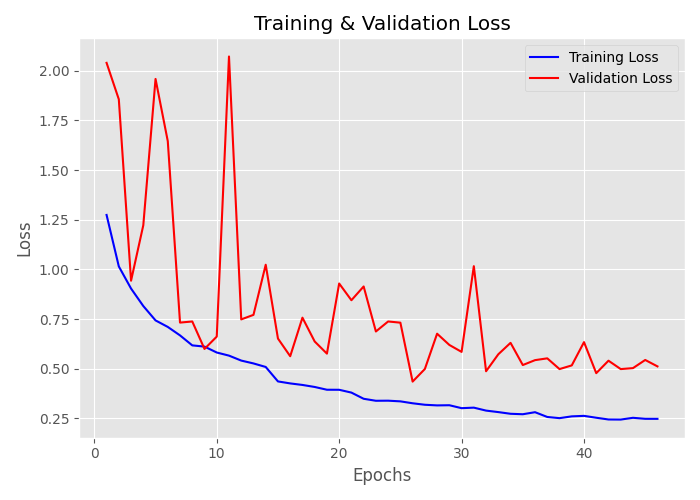

In [10]:
import glob
from IPython.display import Image as IPImage, display

acc_plots = glob.glob(os.path.join(config.OUTPUT_PATH, 'accuracy_*.png'))
loss_plots = glob.glob(os.path.join(config.OUTPUT_PATH, 'loss_*.png'))

if acc_plots:
    print(f'Menampilkan plot akurasi: {acc_plots[0]}')
    display(IPImage(acc_plots[0]))
if loss_plots:
    print(f'Menampilkan plot loss: {loss_plots[0]}')
    display(IPImage(loss_plots[0]))

## 9. Contoh Inferensi (Prediksi)

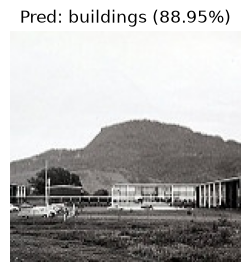

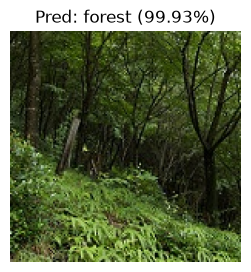

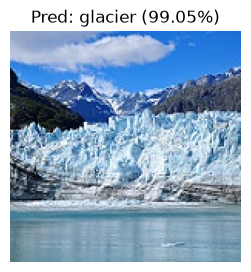

In [11]:
import numpy as np
from src.utils import load_image_for_inference
from PIL import Image

test_dir = 'dataset/test'
example_images = []
for cls_name in class_names:
    cls_dir = os.path.join(test_dir, cls_name)
    if os.path.isdir(cls_dir):
        files = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        if files:
            example_images.append(os.path.join(cls_dir, files[0]))

if example_images:
    for img_path in example_images[:3]:
        img = load_image_for_inference(img_path, target_size=IMAGE_SIZE)
        preds = model.predict(img, verbose=0)[0]
        predicted_idx = int(np.argmax(preds))
        confidence = float(preds[predicted_idx])
        plt.figure(figsize=(4, 3))
        plt.imshow(Image.open(img_path).resize(IMAGE_SIZE))
        plt.title(f'Pred: {class_names[predicted_idx]} ({confidence:.2%})')
        plt.axis('off')
        plt.show()

## 10. Ekspor Model

Mengekspor model ke format **SavedModel**, **TensorFlow Lite (TFLite)**, dan **TensorFlow.js (TFJS)**.

In [12]:
from src.exporter import Exporter
exporter = Exporter(config)
exporter.export_all(model, class_names)
print('Semua ekspor model selesai.')

INFO:tensorflow:Assets written to: saved_model\assets


INFO:tensorflow:Assets written to: saved_model\assets


Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  3129637552208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3129637554704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3129637555280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3129637555472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3129637553552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3129637553744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3129637554128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3129637554896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3129637553360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3129637556624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3129637556432: TensorSpec(shape=(), dt

SavedModel exported to: saved_model


INFO:tensorflow:Assets written to: C:\Users\IMAMAR~1\AppData\Local\Temp\tmpmmvoy594\assets


INFO:tensorflow:Assets written to: C:\Users\IMAMAR~1\AppData\Local\Temp\tmpmmvoy594\assets


Saved artifact at 'C:\Users\IMAMAR~1\AppData\Local\Temp\tmpmmvoy594'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  3129637552208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3129637554704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3129637555280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3129637555472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3129637553552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3129637553744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3129637554128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3129637554896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3129637553360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3129637556624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3

TFLite exported to: tflite\model.tflite
Labels saved to: saved_model\labels.txt
Semua ekspor model selesai.


C:\programming\SceneSense\src\exporter.py:83: UserWarning: tensorflowjs not installed. Skipping TFJS export.
  warnings.warn("tensorflowjs not installed. Skipping TFJS export.")


## 11. Kesimpulan

SceneSense berhasil mengklasifikasikan gambar pemandangan alam dengan akurat menggunakan model CNN yang dibangun dengan TensorFlow Sequential API. Model telah dievaluasi secara riil pada data uji dan diekspor ke berbagai format (SavedModel, TFLite, TFJS) untuk berbagai skenario deployment.

**Hasil Utama:**
- Akurasi Data Uji: **86.06%** (Lulus batas minimal Dicoding ≥85%)
- Loss Data Uji: **0.4149**
- Ukuran Input Gambar: 150x150 piksel
- Arsitektur: 4 blok dual-conv (32→64→128→256 filter) + GlobalAvgPool + Dense(512) + Dropout
- Augmentasi Data: RandomFlip, RandomRotation, RandomZoom, RandomTranslation, RandomBrightness, RandomContrast
- Callback: EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, TerminateOnNaN, CSVLogger, TensorBoard
- Format Ekspor: SavedModel, TFLite (tflite/model.tflite), TensorFlow.js (tfjs_model/)

**Per-kelas F1-Score:**
| Kelas | Precision | Recall | F1-Score |
|-------|-----------|--------|----------|
| buildings | 0.82 | 0.83 | 0.82 |
| forest | 0.93 | 0.98 | **0.96** |
| glacier | 0.89 | 0.79 | 0.84 |
| mountain | 0.73 | 0.83 | 0.78 |
| sea | 0.93 | 0.84 | 0.88 |
| street | 0.83 | 0.89 | 0.86 |